# **Imports**

In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings("ignore")

device = torch.device("xpu" if torch.xpu.is_available() else "cpu")
print("Using device:", device)

Using device: xpu


# **Paths & Data Load**

In [ ]:
BASE_DIR = "../../data"
TRAIN_DIR = os.path.join(BASE_DIR, "train_images")

df = pd.read_csv(os.path.join(BASE_DIR, "train.csv"))

with open(os.path.join(BASE_DIR, "label_num_to_disease_map.json")) as f:
    label_map = json.load(f)
label_map = {int(k): v for k, v in label_map.items()}

df["disease_name"] = df["label"].map(label_map)
num_classes = df["label"].nunique()

print("Total images:", len(df))
print("Number of classes:", num_classes)
df.head()

Total images: 21397
Number of classes: 5


,image_id,label,disease_name
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB)
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD)
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD)


# **Train / Validation / Test Split (Stratified)**

In [3]:
# First split: train (70%) vs temp (30%)
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=42
)

# Second split: temp -> validation (15%) and test (15%)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

# Verify class distribution is preserved
print("\nTrain class distribution:")
print(train_df["label"].value_counts(normalize=True).sort_index())

Train size: 14977
Validation size: 3210
Test size: 3210

Train class distribution:
label
0    0.050811
1    0.102290
2    0.111504
3    0.614943
4    0.120451
Name: proportion, dtype: float64


# **Handle Class Imbalance (Class Weights)**

In [4]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights)

Class weights: tensor([3.9361, 1.9552, 1.7937, 0.3252, 1.6604], device='xpu:0')


# **Data Augmentation & Normalization**

In [5]:
IMG_SIZE = 224  # standard input size for most pretrained CNNs

# Training transforms: includes augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                          std=[0.229, 0.224, 0.225])
])

# Validation/Test transforms: no augmentation, only resize + normalize
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

# **Custom Dataset Class**

In [6]:
class CassavaDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"])
        image = Image.open(img_path).convert("RGB")
        label = row["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

train_dataset = CassavaDataset(train_df, TRAIN_DIR, transform=train_transform)
val_dataset = CassavaDataset(val_df, TRAIN_DIR, transform=eval_transform)
test_dataset = CassavaDataset(test_df, TRAIN_DIR, transform=eval_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Batches -> Train:", len(train_loader), "Val:", len(val_loader), "Test:", len(test_loader))

Batches -> Train: 469 Val: 101 Test: 101


# **Helper Functions: Train, Evaluate, Metrics, Param Count**

In [7]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def get_model_size_mb(model):
    param_size = sum(p.nelement() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.nelement() * b.element_size() for b in model.buffers())
    size_mb = (param_size + buffer_size) / (1024 ** 2)
    return size_mb

def train_one_epoch(model, loader, optimizer, criterion, epoch_num, total_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Progress bar for this epoch's batches (shows how much of the epoch is done)
    pbar = tqdm(loader, desc=f"Epoch {epoch_num}/{total_epochs} [Train]", leave=False)

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Live batch-level stats shown on the progress bar itself
        pbar.set_postfix({
            "batch_loss": f"{loss.item():.4f}",
            "running_acc": f"{correct/total:.4f}"
        })

    return running_loss / total, correct / total

def evaluate(model, loader, criterion, desc="Val"):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc=f"[{desc}]", leave=False)

    with torch.no_grad():
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average="macro")
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    per_class_recall = recall_score(all_labels, all_preds, average=None, zero_division=0)

    return avg_loss, acc, f1, precision, recall, per_class_recall, all_preds, all_labels

# **Full Training Loop Function (Reusable for Every Baseline)**

In [8]:
def plot_final_training_curves(history, model_name):
    """Called ONCE after all epochs finish — shows loss, accuracy, and macro-F1 curves"""
    epochs_range = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Loss curve
    axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
    axes[0].plot(epochs_range, history["val_loss"], label="Val Loss", marker="o")
    axes[0].set_title(f"{model_name} — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy curve
    axes[1].plot(epochs_range, history["train_acc"], label="Train Acc", marker="o")
    axes[1].plot(epochs_range, history["val_acc"], label="Val Acc", marker="o")
    axes[1].set_title(f"{model_name} — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Macro-F1 curve (primary metric)
    axes[2].plot(epochs_range, history["val_f1"], label="Val Macro-F1", marker="o", color="green")
    axes[2].set_title(f"{model_name} — Macro-F1 (Primary Metric)")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Macro-F1")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{model_name}_training_curves.png", dpi=300, bbox_inches="tight")
    plt.show()


def run_training(model, model_name, num_epochs=5, lr=0.0001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}

    start_time = time.time()

    for epoch in range(1, num_epochs + 1):
        epoch_start = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, epoch, num_epochs)
        val_loss, val_acc, val_f1, val_prec, val_rec, val_per_class_recall, _, _ = evaluate(model, val_loader, criterion, desc="Validation")

        epoch_time = time.time() - epoch_start

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        # Simple one-line print after each epoch (no graph yet)
        print(f"[{model_name}] Epoch {epoch}/{num_epochs} ({epoch_time:.1f}s) | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} Macro-F1: {val_f1:.4f}")

    training_time = time.time() - start_time

    # Final test evaluation
    test_loss, test_acc, test_f1, test_prec, test_rec, test_per_class_recall, test_preds, test_labels = evaluate(model, test_loader, criterion, desc="Test")

    total_params, trainable_params = count_parameters(model)
    model_size = get_model_size_mb(model)

    results = {
        "model_name": model_name,
        "test_f1_macro": test_f1,
        "test_recall_macro": test_rec,
        "test_precision_macro": test_prec,
        "test_accuracy": test_acc,
        "test_per_class_recall": test_per_class_recall,
        "training_time_sec": training_time,
        "total_params": total_params,
        "model_size_mb": model_size,
        "history": history,
        "test_preds": test_preds,
        "test_labels": test_labels
    }

    print(f"\n[{model_name}] FINAL TEST -> Macro-F1: {test_f1:.4f} | Macro-Recall: {test_rec:.4f} | "
          f"Accuracy: {test_acc:.4f} | Params: {total_params:,} | "
          f"Size: {model_size:.2f} MB | Time: {training_time:.1f}s\n")

    # Graph shown ONCE, after all epochs are done
    # plot_final_training_curves(history, model_name)

    return model, results

# **Baseline 1: Simple CNN (from scratch, no pretraining)**

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

simple_cnn = SimpleCNN(num_classes=num_classes)
simple_cnn, results_simplecnn = run_training(simple_cnn, "SimpleCNN", num_epochs=5)

Epoch 1/5 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

[SimpleCNN] Epoch 1/5 (225.8s) | Train Loss: 1.4629 Acc: 0.4494 | Val Loss: 1.4563 Acc: 0.6162 Macro-F1: 0.3516


Epoch 2/5 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

...

Epoch 5/5 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

[SimpleCNN] Epoch 5/5 (116.9s) | Train Loss: 1.2515 Acc: 0.5694 | Val Loss: 1.2587 Acc: 0.5202 Macro-F1: 0.4166


[Test]:   0%|          | 0/101 [00:00<?, ?it/s]


[SimpleCNN] FINAL TEST -> Macro-F1: 0.4046 | Macro-Recall: 0.4901 | Accuracy: 0.5081 | Params: 390,661 | Size: 1.49 MB | Time: 713.1s



# **Baseline 2: MobileNetV2 (pretrained, lightweight)**

In [10]:
mobilenet = models.mobilenet_v2(weights="IMAGENET1K_V1")
mobilenet.classifier[1] = nn.Linear(mobilenet.last_channel, num_classes)

mobilenet, results_mobilenet = run_training(mobilenet, "MobileNetV2", num_epochs=5)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\Rafsun/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:01<00:00, 10.8MB/s]


Epoch 1/5 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

[MobileNetV2] Epoch 1/5 (174.4s) | Train Loss: 1.0096 Acc: 0.6569 | Val Loss: 0.8408 Acc: 0.7717 Macro-F1: 0.6458


...

Epoch 5/5 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

[MobileNetV2] Epoch 5/5 (164.9s) | Train Loss: 0.6594 Acc: 0.7946 | Val Loss: 0.7671 Acc: 0.7676 Macro-F1: 0.6667


[Test]:   0%|          | 0/101 [00:00<?, ?it/s]


[MobileNetV2] FINAL TEST -> Macro-F1: 0.6821 | Macro-Recall: 0.7341 | Accuracy: 0.7776 | Params: 2,230,277 | Size: 8.64 MB | Time: 816.7s



# **Baseline 3: ResNet50 (pretrained, heavier)**

In [11]:
resnet50 = models.resnet50(weights="IMAGENET1K_V1")
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)

resnet50, results_resnet50 = run_training(resnet50, "ResNet50", num_epochs=5)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\Rafsun/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:09<00:00, 10.4MB/s]


Epoch 1/5 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

[ResNet50] Epoch 1/5 (214.5s) | Train Loss: 0.9980 Acc: 0.6758 | Val Loss: 0.8779 Acc: 0.7505 Macro-F1: 0.6375


...

Epoch 5/5 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

[ResNet50] Epoch 5/5 (197.6s) | Train Loss: 0.6543 Acc: 0.8019 | Val Loss: 0.7433 Acc: 0.7601 Macro-F1: 0.6583


[Test]:   0%|          | 0/101 [00:00<?, ?it/s]


[ResNet50] FINAL TEST -> Macro-F1: 0.6676 | Macro-Recall: 0.7320 | Accuracy: 0.7657 | Params: 23,518,277 | Size: 89.92 MB | Time: 1028.9s



# **Baseline 4: EfficientNet-B0 (pretrained)**

In [12]:
effnet = models.efficientnet_b0(weights="IMAGENET1K_V1")
effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, num_classes)

effnet, results_effnet = run_training(effnet, "EfficientNet-B0", num_epochs=5)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Rafsun/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:02<00:00, 9.16MB/s]


Epoch 1/5 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

[EfficientNet-B0] Epoch 1/5 (177.9s) | Train Loss: 1.0904 Acc: 0.6487 | Val Loss: 0.8340 Acc: 0.7617 Macro-F1: 0.6412


...

Epoch 5/5 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/101 [00:00<?, ?it/s]

[EfficientNet-B0] Epoch 5/5 (168.2s) | Train Loss: 0.5789 Acc: 0.8243 | Val Loss: 0.6936 Acc: 0.8028 Macro-F1: 0.7154


[Test]:   0%|          | 0/101 [00:00<?, ?it/s]


[EfficientNet-B0] FINAL TEST -> Macro-F1: 0.7100 | Macro-Recall: 0.7534 | Accuracy: 0.8065 | Params: 4,013,953 | Size: 15.47 MB | Time: 852.2s



# **Final Baseline Summary Table**

In [13]:
all_results = [results_simplecnn, results_mobilenet, results_resnet50, results_effnet]

summary_table = pd.DataFrame([{
    "Model": r["model_name"],
    "Macro F1 (Primary Metric)": round(r["test_f1_macro"], 4),
    "Macro Recall": round(r["test_recall_macro"], 4),
    "Macro Precision": round(r["test_precision_macro"], 4),
    "Test Accuracy": round(r["test_accuracy"], 4),
    "Training Time (s)": round(r["training_time_sec"], 1),
    "Total Params": f"{r['total_params']:,}",
    "Model Size (MB)": round(r["model_size_mb"], 2)
} for r in all_results])

# Sort by primary metric (macro-F1), not accuracy
summary_table = summary_table.sort_values("Macro F1 (Primary Metric)", ascending=False)

print(summary_table.to_string(index=False))
summary_table.to_csv("baseline_results_summary.csv", index=False)

          Model  Macro F1 (Primary Metric)  Macro Recall  Macro Precision  Test Accuracy  Training Time (s) Total Params  Model Size (MB)
EfficientNet-B0                     0.7100        0.7534           0.6806         0.8065              852.2    4,013,953            15.47
    MobileNetV2                     0.6821        0.7341           0.6550         0.7776              816.7    2,230,277             8.64
       ResNet50                     0.6676        0.7320           0.6383         0.7657             1028.9   23,518,277            89.92
      SimpleCNN                     0.4046        0.4901           0.4016         0.5081              713.1      390,661             1.49


# **Classification Report for Each Baseline**

In [14]:
class_names = [label_map[i] for i in range(num_classes)]

for r in all_results:
    print(f"\n===== Classification Report: {r['model_name']} =====")
    print(classification_report(r["test_labels"], r["test_preds"], target_names=class_names))


===== Classification Report: SimpleCNN =====
                                     precision    recall  f1-score   support

     Cassava Bacterial Blight (CBB)       0.22      0.71      0.33       163
Cassava Brown Streak Disease (CBSD)       0.24      0.42      0.30       329
         Cassava Green Mottle (CGM)       0.27      0.38      0.32       358
       Cassava Mosaic Disease (CMD)       0.91      0.55      0.69      1974
                            Healthy       0.36      0.39      0.38       386

                           accuracy                           0.51      3210
                          macro avg       0.40      0.49      0.40      3210
                       weighted avg       0.67      0.51      0.55      3210


===== Classification Report: MobileNetV2 =====
                                     precision    recall  f1-score   support

     Cassava Bacterial Blight (CBB)       0.48      0.71      0.57       163
Cassava Brown Streak Disease (CBSD)       0.69      0.6

# **Confusion Matrices**

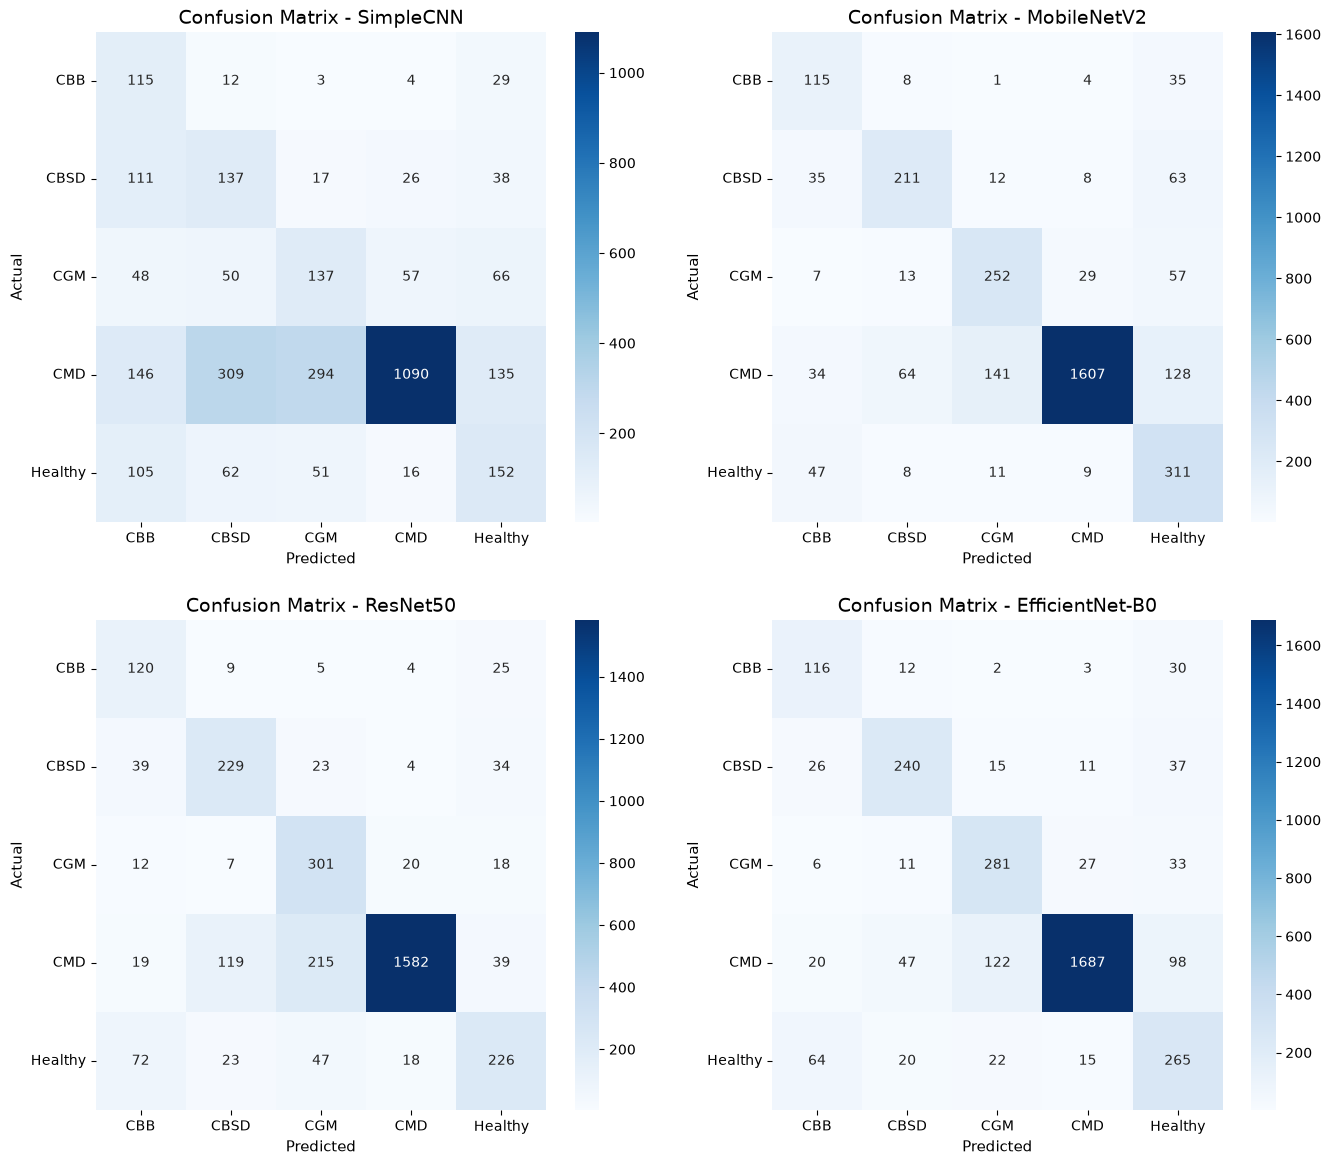

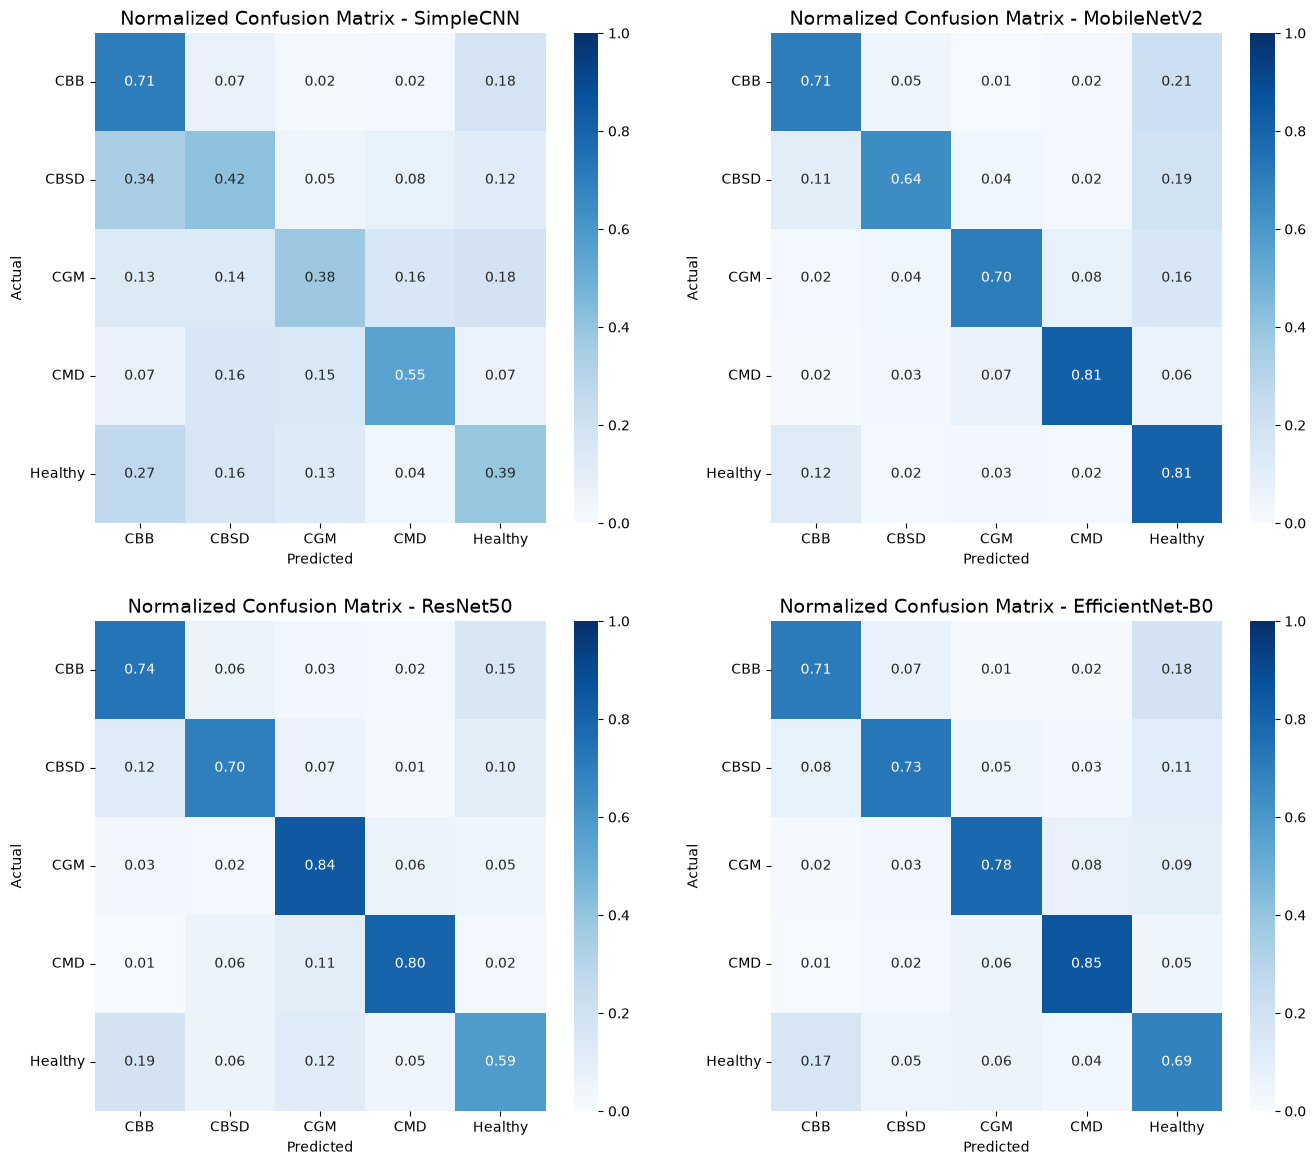

In [26]:
short_class_names = [
    "CBB",
    "CBSD",
    "CGM",
    "CMD",
    "Healthy"
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, r in enumerate(all_results):

    cm = confusion_matrix(
        r["test_labels"],
        r["test_preds"]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i],
        xticklabels=short_class_names,
        yticklabels=short_class_names,
        annot_kws={"size": 10}
    )

    axes[i].set_title(
        f"Confusion Matrix - {r['model_name']}",
        fontsize=14
    )

    axes[i].set_xlabel("Predicted", fontsize=11)
    axes[i].set_ylabel("Actual", fontsize=11)

    axes[i].tick_params(
        axis="x",
        rotation=0,
        labelsize=10
    )

    axes[i].tick_params(
        axis="y",
        rotation=0,
        labelsize=10
    )
plt.savefig("baseline_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, r in enumerate(all_results):

    cm = confusion_matrix(
        r["test_labels"],
        r["test_preds"]
    )

    # Normalize each row
    cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        ax=axes[i],
        xticklabels=short_class_names,
        yticklabels=short_class_names,
        vmin=0,
        vmax=1,
        annot_kws={"size": 10}
    )

    axes[i].set_title(
        f"Normalized Confusion Matrix - {r['model_name']}",
        fontsize=14
    )

    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

    axes[i].tick_params(axis="x", rotation=0)
    axes[i].tick_params(axis="y", rotation=0)


plt.savefig("baseline_confusion_matrices_percentage.png", dpi=300, bbox_inches="tight")
plt.show()

# **Training Curves Comparison**

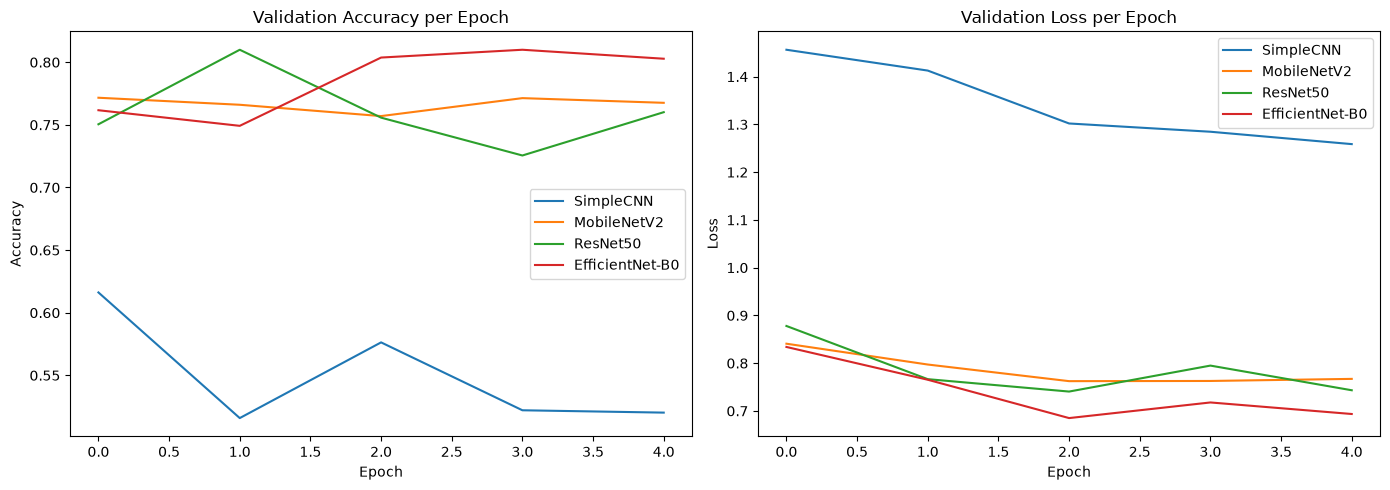

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for r in all_results:
    axes[0].plot(r["history"]["val_acc"], label=r["model_name"])
    axes[1].plot(r["history"]["val_loss"], label=r["model_name"])

axes[0].set_title("Validation Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].set_title("Validation Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig("baseline_training_curves.png", dpi=300, bbox_inches="tight")
plt.show()

# **Bar Chart: Accuracy vs Params vs Time**

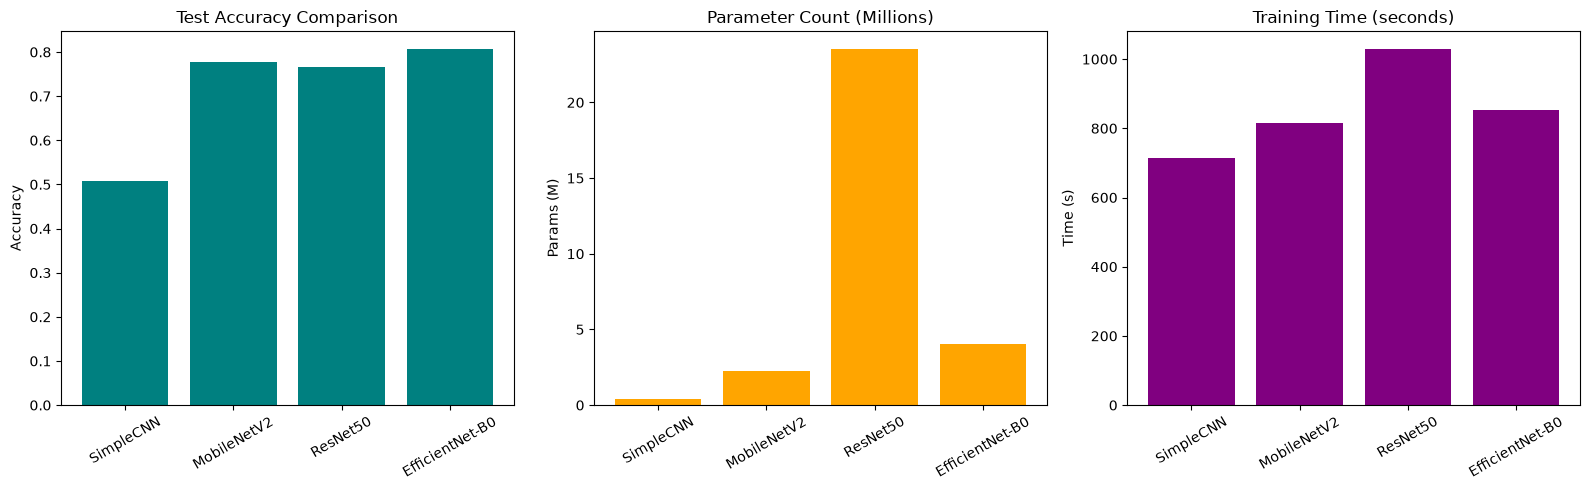

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_names = [r["model_name"] for r in all_results]
accs = [r["test_accuracy"] for r in all_results]
params = [r["total_params"]/1e6 for r in all_results]  # in millions
times = [r["training_time_sec"] for r in all_results]

axes[0].bar(models_names, accs, color="teal")
axes[0].set_title("Test Accuracy Comparison")
axes[0].set_ylabel("Accuracy")
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(models_names, params, color="orange")
axes[1].set_title("Parameter Count (Millions)")
axes[1].set_ylabel("Params (M)")
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(models_names, times, color="purple")
axes[2].set_title("Training Time (seconds)")
axes[2].set_ylabel("Time (s)")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("baseline_comparison_bars.png", dpi=300, bbox_inches="tight")
plt.show()

# **Save Best Baseline Model**

In [27]:
best_baseline = max(all_results, key=lambda x: x["test_f1_macro"])
print("Best baseline model:", best_baseline["model_name"])

# Save results as JSON for reuse in the proposed model notebook
import pickle
with open("baseline_results.pkl", "wb") as f:
    pickle.dump(all_results, f)

print("Baseline results saved to baseline_results.pkl")

Best baseline model: EfficientNet-B0
Baseline results saved to baseline_results.pkl
